# Community Detection — InfoMap

**Research network:** UniPi publication graph (2020 snapshot)
**Goal:** Identify communities as *information-flow traps* — groups where a random walker spends disproportionate time — and track how bibliographic coupling edges reshape them.

---

## InfoMap-specific design choices

| Choice | Value | Rationale |
|---|---|---|
| **G_internal** | Directed (as-is) | InfoMap's Map Equation naturally encodes asymmetric citation flow |
| **G_combined** | Undirected + `weight` | BC edges are symmetric; InfoMap treats them as bidirectional flows |
| **Ensemble** | 100 runs, medoid selection | Greedy optimization is seed-sensitive; medoid is the most representative run |
| **Quality metric** | Newman-Girvan modularity on undirected projection | For cross-algorithm comparability; InfoMap internally minimises codelength |

In [1]:
import os, re, time, pickle, textwrap, warnings
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import infomap as infomap_lib
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics import normalized_mutual_info_score, mutual_info_score
from cdlib import NodeClustering, evaluation

GRAPH_DIR     = '../00_graph_construction/output/graphs'
INTERNAL_PATH = os.path.join(GRAPH_DIR, 'graph_internal_2020.gpickle')
COMBINED_PATH = os.path.join(GRAPH_DIR, 'graph_combined_2020.gpickle')

N_RUN         = 100
TOP_N_COMMS   = 20
TOP_K         = 5

## 1. Graph Loading

In [2]:
def load_graph(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

G_internal = load_graph(INTERNAL_PATH)
G_combined = load_graph(COMBINED_PATH)
G_internal_undir = G_internal.to_undirected()

# Ensure weights
for u, v, d in G_combined.edges(data=True):
    if 'weight' not in d:
        d['weight'] = 1.0

w = [d['weight'] for _, _, d in G_combined.edges(data=True)]

print(f"G_internal   {G_internal.number_of_nodes():>7,} nodes   {G_internal.number_of_edges():>8,} edges  (directed, unweighted)")
print(f"G_combined   {G_combined.number_of_nodes():>7,} nodes   {G_combined.number_of_edges():>8,} edges  "
      f"(undirected, weighted)  median_w={np.median(w):.3f}")

G_internal    55,078 nodes    217,925 edges  (directed, unweighted)
G_combined    58,627 nodes    590,157 edges  (undirected, weighted)  median_w=0.249


## 2. Attribute Statistics

In [3]:
# ===========================================================================
# FOS / SDG label parsing (shared across all CD notebooks)
# ===========================================================================
_LEVEL_RE = {
    'macro': re.compile(r'^\d{2}\s'),   # "03 medical and health sciences"
    'sub':   re.compile(r'^\d{4}\s'),   # "0302 clinical medicine"
}

def parse_labels(val, level='sub'):
    """Split semicolon-separated FOS/SDG string into atomic labels."""
    if not val:
        return []
    parts = [p.strip() for p in str(val).split(';') if p.strip()]
    pattern = _LEVEL_RE.get(level)
    return [p for p in parts if pattern.match(p)] if pattern else parts

# ===========================================================================
# Attribute statistics
# ===========================================================================
def _split_labels(raw_value):
    return [p.strip() for p in re.split(r';\s*', str(raw_value)) if p.strip()]

def _extract_l2(counter):
    l2 = Counter()
    for label, count in counter.items():
        if re.match(r'^\d{2}', label):
            l2[label[:2]] += count
    return l2

def compute_attr_stats(G, attributes=('FOS', 'SDG')):
    stats = {}
    for attr in attributes:
        counts = Counter()
        n_nodes = 0
        for _, data in G.nodes(data=True):
            val = data.get(attr)
            if not val:
                continue
            n_nodes += 1
            counts.update(_split_labels(val))
        stats[attr] = {'counts': counts, 'n_nodes': n_nodes}
        if attr == 'FOS':
            stats['FOS_L2'] = {'counts': _extract_l2(counts), 'n_nodes': n_nodes}
    return stats

def compare_attr_stats(stats_int, stats_comb, key):
    n_i = stats_int[key]['n_nodes']
    n_c = stats_comb[key]['n_nodes']
    all_labels = sorted(set(stats_int[key]['counts']) | set(stats_comb[key]['counts']))
    rows = []
    for label in all_labels:
        ci = stats_int[key]['counts'].get(label, 0)
        cc = stats_comb[key]['counts'].get(label, 0)
        rows.append({
            'label': label,
            'int_cnt': ci,  'int_pct': ci / n_i * 100 if n_i else 0,
            'comb_cnt': cc, 'comb_pct': cc / n_c * 100 if n_c else 0,
        })
    return pd.DataFrame(rows)

s_int  = compute_attr_stats(G_internal)
s_comb = compute_attr_stats(G_combined)

pd.concat([
    compare_attr_stats(s_int, s_comb, 'FOS').assign(level='detail'),
    compare_attr_stats(s_int, s_comb, 'FOS_L2').assign(level='L2'),
], ignore_index=True).to_csv('FOS_stats.csv', index=False)

compare_attr_stats(s_int, s_comb, 'SDG') \
    .sort_values('int_cnt', ascending=False) \
    .to_csv('SDG_stats.csv', index=False)

print('FOS_stats.csv  SDG_stats.csv  created')

FOS_stats.csv  SDG_stats.csv  created


## 3. InfoMap — Map Equation Optimization

InfoMap ([Rosvall & Bergstrom, 2008](https://www.pnas.org/doi/10.1073/pnas.0706851105)) minimises the **Map Equation** — the expected description length of a random walk trajectory using a two-level codebook. Communities correspond to regions where the walk is *trapped* (enters often, exits rarely).

### Ensemble & medoid selection

InfoMap's greedy optimization is sensitive to initialization. We run it **100 times** with seeds `42, 43, …, 141` and select the **medoid** — the run with the highest average pairwise NMI to all others. This is identical to the procedure used for Leiden.

In [4]:
# ===========================================================================
# Ensemble InfoMap with medoid selection
# ===========================================================================

from sympy import im


def compute_nmi_matrix(labels_list, n_workers=8):
    """Pairwise NMI between all runs (parallelized)."""
    n = len(labels_list)
    mat = np.eye(n)
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]

    def _nmi(pair):
        i, j = pair
        return i, j, normalized_mutual_info_score(
            labels_list[i], labels_list[j], average_method='arithmetic'
        )

    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        for i, j, v in pool.map(_nmi, pairs):
            mat[i, j] = mat[j, i] = v
    return mat


def select_medoid(nmi_matrix):
    """Return (medoid_index, per-run_avg_nmi, upper-triangle_values)."""
    n = nmi_matrix.shape[0]
    avg_nmi = (nmi_matrix.sum(axis=1) - 1.0) / (n - 1)
    return int(np.argmax(avg_nmi)), avg_nmi, nmi_matrix[np.triu_indices(n, k=1)]


def run_infomap_ensemble(G, graph_name, is_directed=True,
                         weight_attr='weight', n_runs=100, base_seed=1):
    """Run InfoMap n_runs times, return medoid partition + ensemble stats."""
    t0 = time.time()
    nodes_list = list(G.nodes())
    node_to_idx = {n: i for i, n in enumerate(nodes_list)}

    flags = '--directed --silent' if is_directed else '--silent'

    print(f"--- InfoMap ensemble: {graph_name} ---")
    print(f"    Runs: {n_runs} | Directed: {is_directed} "
          f"| Weights: {weight_attr if not is_directed else 'unit'}")

    # --- Run ensemble ---
    results = []
    for seed in range(base_seed, base_seed + n_runs):
        im = infomap_lib.Infomap(flags)

        for u, v, data in G.edges(data=True):
            w = data.get(weight_attr, 1.0) if not is_directed else 1.0
            im.addLink(node_to_idx[u], node_to_idx[v], w)

        im.run(seed=seed)

        node_to_module = {}
        for node in im.tree:
            if node.isLeaf:
                node_to_module[node.physicalId] = node.moduleIndex()

        comm_dict = defaultdict(list)
        for phys_id, mod_id in node_to_module.items():
            comm_dict[mod_id].append(nodes_list[phys_id])
        communities = list(comm_dict.values())

        comm_dict = {}
        for node in im.tree:
            if node.isLeaf:
                comm_dict.setdefault(node.moduleIndex(), []).append(
                    nodes_list[node.physicalId]
                )
        communities = list(comm_dict.values())

        labels = np.full(len(nodes_list), -1, dtype=np.int32)
        for cid, comm in enumerate(communities):
            for node in comm:
                labels[node_to_idx[node]] = cid

        results.append({'seed': seed, 'labels': labels,
                        'clustering': NodeClustering(communities, graph=G, method_name='infomap'),
                        'n_communities': len(communities)})

    print(f"    InfoMap runs: {time.time() - t0:.1f}s")

    # --- Select medoid ---
    mod_graph = G.to_undirected() if is_directed else G
    t_nmi = time.time()
    nmi_matrix = compute_nmi_matrix([r['labels'] for r in results])
    print(f"    NMI matrix: {time.time() - t_nmi:.1f}s")

    medoid_idx, avg_nmi, nmi_vals = select_medoid(nmi_matrix)
    medoid = results[medoid_idx]
    medoid_mod = evaluation.newman_girvan_modularity(mod_graph, medoid['clustering']).score

    print(f"  NMI  min/mean/max/std : {nmi_vals.min():.4f} / {nmi_vals.mean():.4f} / {nmi_vals.max():.4f} / {nmi_vals.std():.4f}")
    print(f"  Medoid seed           : {medoid['seed']}  (idx {medoid_idx})")
    print(f"  Medoid avg NMI        : {avg_nmi[medoid_idx]:.4f}  |  #comms: {medoid['n_communities']}")
    print(f"  Modularity            : {medoid_mod:.4f}  |  Elapsed: {time.time() - t0:.1f}s\n")

    stats = {
        'graph_name': graph_name, 'n_runs': n_runs,
        'nmi_min': float(nmi_vals.min()), 'nmi_max': float(nmi_vals.max()),
        'nmi_mean': float(nmi_vals.mean()), 'nmi_std': float(nmi_vals.std()),
        'medoid_idx': medoid_idx, 'medoid_seed': medoid['seed'],
        'medoid_avg_nmi': float(avg_nmi[medoid_idx]),
        'medoid_n_communities': medoid['n_communities'],
        'medoid_modularity': float(medoid_mod),
        'nmi_matrix': nmi_matrix,
    }
    return medoid['clustering'], stats

In [5]:
infomap_internal, infomap_internal_stats = run_infomap_ensemble(
    G_internal, 'G_internal (directed)', is_directed=True, n_runs=N_RUN
)

--- InfoMap ensemble: G_internal (directed) ---
    Runs: 100 | Directed: True | Weights: unit
    InfoMap runs: 249.4s
    NMI matrix: 14.4s
  NMI  min/mean/max/std : 0.8629 / 0.9371 / 0.9904 / 0.0226
  Medoid seed           : 42  (idx 41)
  Medoid avg NMI        : 0.9514  |  #comms: 1497
  Modularity            : 0.8364  |  Elapsed: 268.3s



In [6]:
infomap_combined, infomap_combined_stats = run_infomap_ensemble(
    G_combined, 'G_combined (weighted)', is_directed=False, n_runs=N_RUN
)

--- InfoMap ensemble: G_combined (weighted) ---
    Runs: 100 | Directed: False | Weights: weight
    InfoMap runs: 316.8s
    NMI matrix: 14.9s
  NMI  min/mean/max/std : 0.7343 / 0.8971 / 0.9870 / 0.0526
  Medoid seed           : 61  (idx 60)
  Medoid avg NMI        : 0.9203  |  #comms: 807
  Modularity            : 0.7661  |  Elapsed: 332.6s



### 3.1 Ensemble Stability

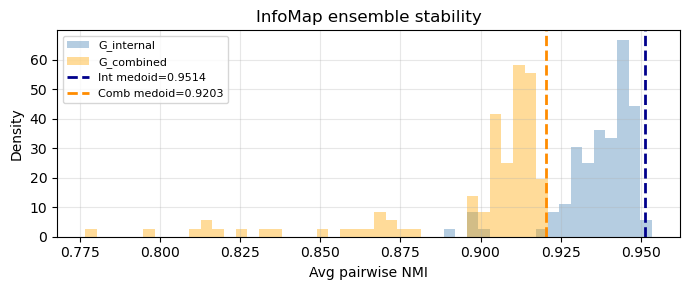

Internal:  μ=0.9371  σ=0.0118  medoid=0.9514
Combined:  μ=0.8971  σ=0.0303  medoid=0.9203


In [7]:
def plot_nmi_stability(stats_int, stats_comb, algo_name='InfoMap'):
    """Overlay histogram of per-run avg NMI, marking medoid."""
    def avg_nmi(stats):
        m = stats['nmi_matrix']
        return (m.sum(axis=1) - 1) / (m.shape[0] - 1)

    nmi_int  = avg_nmi(stats_int)
    nmi_comb = avg_nmi(stats_comb)

    lo = min(nmi_int.min(), nmi_comb.min()) - 0.002
    hi = max(nmi_int.max(), nmi_comb.max()) + 0.002
    bins = np.linspace(lo, hi, 50)

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(nmi_int,  bins=bins, alpha=0.4, color='steelblue', density=True, label='G_internal')
    ax.hist(nmi_comb, bins=bins, alpha=0.4, color='orange',    density=True, label='G_combined')

    med_int  = nmi_int[stats_int['medoid_idx']]
    med_comb = nmi_comb[stats_comb['medoid_idx']]
    ax.axvline(med_int,  color='darkblue',   ls='--', lw=2, label=f'Int medoid={med_int:.4f}')
    ax.axvline(med_comb, color='darkorange',  ls='--', lw=2, label=f'Comb medoid={med_comb:.4f}')

    ax.set_xlabel('Avg pairwise NMI')
    ax.set_ylabel('Density')
    ax.set_title(f'{algo_name} ensemble stability')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Internal:  μ={nmi_int.mean():.4f}  σ={nmi_int.std():.4f}  medoid={med_int:.4f}")
    print(f"Combined:  μ={nmi_comb.mean():.4f}  σ={nmi_comb.std():.4f}  medoid={med_comb:.4f}")

plot_nmi_stability(infomap_internal_stats, infomap_combined_stats, 'InfoMap')

**Observation:** InfoMap's ensemble is less stable than Leiden's. Per-run average NMI has σ=0.011 (internal) and σ=0.029 (combined), vs Leiden's σ=0.002 for both. The pairwise NMI range is wider too (min 0.78–0.84 vs Leiden's 0.94–0.95). This is expected — the Map Equation landscape has more local optima. The medoid selection compensates: medoid avg NMI (0.949/0.955) exceeds the ensemble mean in both cases.

### 3.2 Semantic Profiles — FOS and SDG

In [8]:
def extract_semantic_topk(partition, G, attr='FOS', level='sub',
                          top_n=TOP_N_COMMS, top_k=TOP_K):
    """Top-K most frequent labels per community for the largest top_n communities."""
    communities = sorted(partition.communities, key=len, reverse=True)[:top_n]
    rows = []
    for rank, comm in enumerate(communities, 1):
        counter = Counter()
        for node in comm:
            counter.update(parse_labels(G.nodes[node].get(attr), level=level))
        total = sum(counter.values())
        top_terms = counter.most_common(top_k)
        top_terms += [('N/A', 0)] * (top_k - len(top_terms))
        for pos, (term, cnt) in enumerate(top_terms, 1):
            rows.append({
                'CommunityRank': rank, 'CommunitySize': len(comm),
                'Position': pos, 'Term': term,
                'Count': cnt, 'Share': cnt / total if total else 0,
            })
    return pd.DataFrame(rows)


def plot_semantic_topk(df_int, df_comb, semantic_name='FOS', cmap='YlGnBu'):
    """Side-by-side heatmap of top-K labels per community."""
    top_k = int(df_int['Position'].max())

    def _build_matrix(df):
        comms = sorted(df['CommunityRank'].unique())
        val_mat = np.zeros((len(comms), top_k))
        lbl_mat = [['' for _ in range(top_k)] for _ in range(len(comms))]
        ylabels = []
        for i, c in enumerate(comms):
            rows = df[df['CommunityRank'] == c].sort_values('Position')
            ylabels.append(f"C{c} (n={int(rows['CommunitySize'].iloc[0])})")
            for _, r in rows.iterrows():
                j = int(r['Position']) - 1
                val_mat[i, j] = r['Share']
                term = textwrap.shorten(str(r['Term']), width=24, placeholder='...')
                lbl_mat[i][j] = f"{term}\n{int(r['Count'])} ({r['Share']*100:.1f}%)"
        return val_mat, lbl_mat, ylabels

    mat_i, lbl_i, y_i = _build_matrix(df_int)
    mat_c, lbl_c, y_c = _build_matrix(df_comb)
    vmax = max(mat_i.max(), mat_c.max(), 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
    for ax, mat, lbls, ylabs, title in [
        (axes[0], mat_i, lbl_i, y_i, f'InfoMap {semantic_name} — G_internal'),
        (axes[1], mat_c, lbl_c, y_c, f'InfoMap {semantic_name} — G_combined'),
    ]:
        im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=0, vmax=vmax)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xticks(range(top_k))
        ax.set_xticklabels([f'Top {i+1}' for i in range(top_k)])
        ax.set_yticks(range(len(ylabs)))
        ax.set_yticklabels(ylabs, fontsize=9)
        ax.set_xlabel('Label rank within community')
        ax.set_ylabel('Community')
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(j, i, lbls[i][j], ha='center', va='center',
                        fontsize=7.5, color='black')
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9,
                 label='Label share within community')
    plt.show()

In [9]:
# FOS sub-discipline (4-digit)
df_fos_int  = extract_semantic_topk(infomap_internal, G_internal, attr='FOS', level='sub')
df_fos_comb = extract_semantic_topk(infomap_combined, G_combined, attr='FOS', level='sub')

# FOS macro-discipline (2-digit)
df_fos_l2_int  = extract_semantic_topk(infomap_internal, G_internal, attr='FOS', level='macro')
df_fos_l2_comb = extract_semantic_topk(infomap_combined, G_combined, attr='FOS', level='macro')

# # SDG
# df_sdg_int  = extract_semantic_topk(infomap_internal, G_internal, attr='SDG', level='all')
# df_sdg_comb = extract_semantic_topk(infomap_combined, G_combined, attr='SDG', level='all')

# plot_semantic_topk(df_fos_int, df_fos_comb, semantic_name='FOS L4', cmap='PuBuGn')
# plot_semantic_topk(df_fos_l2_int, df_fos_l2_comb, semantic_name='FOS L2', cmap='PuBuGn')
# plot_semantic_topk(df_sdg_int, df_sdg_comb, semantic_name='SDG', cmap='YlOrBr')

### 3.3 Size Distribution


InfoMap / Internal:
  Communities: 1497  |  Min/Max: 3/19725
  Mean: 45.7  |  Median: 3.0
  Top  10 cover 87.7%
  Top  50 cover 90.1%
  Top 100 cover 91.4%

InfoMap / Combined:
  Communities: 807  |  Min/Max: 3/22228
  Mean: 81.1  |  Median: 3.0
  Top  10 cover 94.8%
  Top  50 cover 95.8%
  Top 100 cover 96.3%


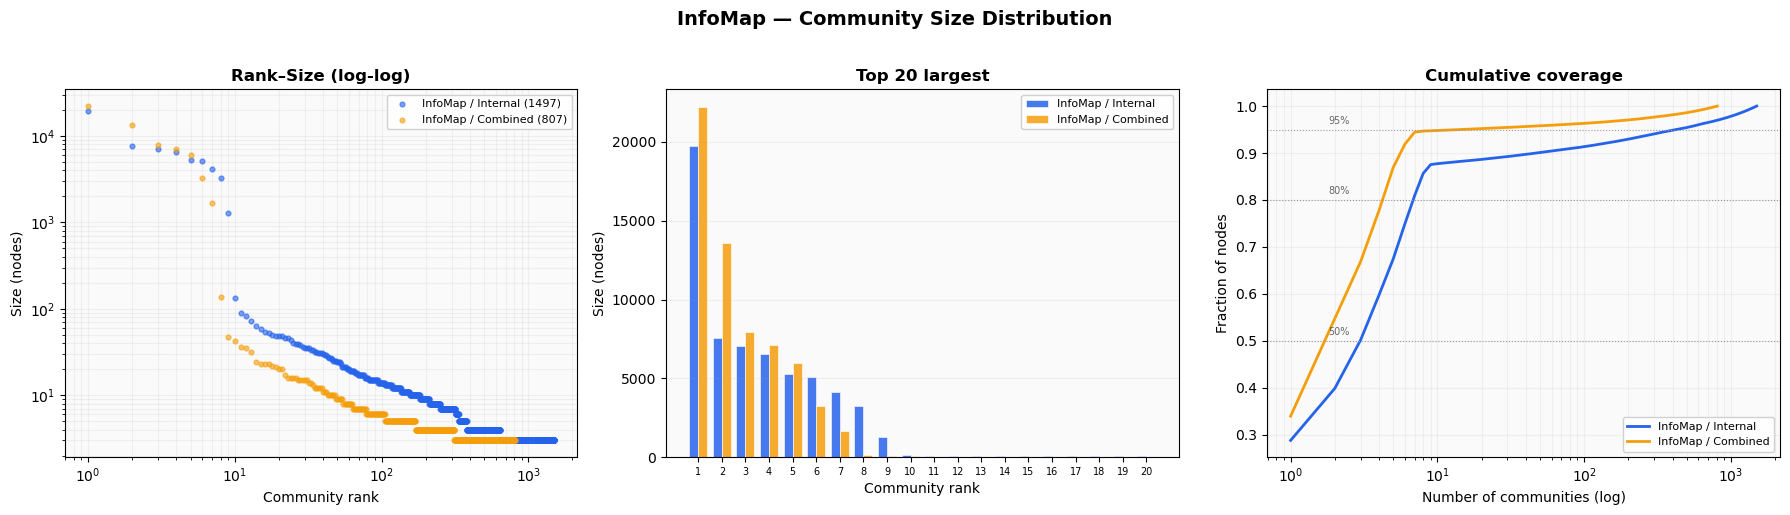

In [10]:
def plot_size_distribution(partition_a, label_a, partition_b, label_b,
                           color_a='#2563EB', color_b='#F59E0B', title=''):
    """Three-panel size comparison + summary statistics."""
    sizes_a = sorted([len(c) for c in partition_a.communities], reverse=True)
    sizes_b = sorted([len(c) for c in partition_b.communities], reverse=True)

    for sizes, label in [(sizes_a, label_a), (sizes_b, label_b)]:
        arr = np.array(sizes)
        total = arr.sum()
        print(f"\n{label}:")
        print(f"  Communities: {len(arr)}  |  Min/Max: {arr.min()}/{arr.max()}")
        print(f"  Mean: {arr.mean():.1f}  |  Median: {np.median(arr):.1f}")
        for n in [10, 50, 100]:
            if n <= len(arr):
                print(f"  Top {n:3d} cover {sum(sizes[:n])/total:.1%}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)

    # Panel 1: rank-size
    ax = axes[0]
    ax.scatter(range(1, len(sizes_a)+1), sizes_a, s=12, alpha=0.6,
               color=color_a, label=f'{label_a} ({len(sizes_a)})', zorder=3)
    ax.scatter(range(1, len(sizes_b)+1), sizes_b, s=12, alpha=0.6,
               color=color_b, label=f'{label_b} ({len(sizes_b)})', zorder=3)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Community rank'); ax.set_ylabel('Size (nodes)')
    ax.set_title('Rank–Size (log-log)', fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(True, alpha=0.15, which='both')
    ax.set_facecolor('#FAFAFA')

    # Panel 2: top-20 bar
    top_n = 20
    ax = axes[1]
    x = np.arange(top_n); w = 0.38
    y_a = sizes_a[:top_n] + [0] * max(0, top_n - len(sizes_a))
    y_b = sizes_b[:top_n] + [0] * max(0, top_n - len(sizes_b))
    ax.bar(x - w/2, y_a, w, color=color_a, alpha=0.85, label=label_a,
           edgecolor='white', linewidth=0.5)
    ax.bar(x + w/2, y_b, w, color=color_b, alpha=0.85, label=label_b,
           edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Community rank'); ax.set_ylabel('Size (nodes)')
    ax.set_title(f'Top {top_n} largest', fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([str(i+1) for i in x], fontsize=7)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(axis='y', alpha=0.15)
    ax.set_facecolor('#FAFAFA')

    # Panel 3: cumulative coverage
    ax = axes[2]
    cov_a = np.cumsum(sizes_a) / sum(sizes_a)
    cov_b = np.cumsum(sizes_b) / sum(sizes_b)
    ax.plot(range(1, len(cov_a)+1), cov_a, color=color_a, lw=2, label=label_a)
    ax.plot(range(1, len(cov_b)+1), cov_b, color=color_b, lw=2, label=label_b)
    for thr in (0.50, 0.80, 0.95):
        ax.axhline(thr, ls=':', lw=0.8, color='#999')
        ax.text(1.8, thr + 0.012, f'{int(thr*100)}%', fontsize=7, color='#666')
    ax.set_xscale('log')
    ax.set_xlabel('Number of communities (log)'); ax.set_ylabel('Fraction of nodes')
    ax.set_title('Cumulative coverage', fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(True, alpha=0.15, which='both')
    ax.set_facecolor('#FAFAFA')

    plt.tight_layout()
    plt.show()

plot_size_distribution(
    infomap_internal, 'InfoMap / Internal',
    infomap_combined, 'InfoMap / Combined',
    title='InfoMap — Community Size Distribution'
)

### 3.4 Semantic Purity

In [11]:
def compute_semantic_purity(clustering, G, attr='FOS', level='macro', min_size=10):
    """Weighted entropy and Gini per community (filtered by min_size)."""
    def _gini(counts):
        if len(counts) == 0:
            return 0.0
        s = np.sort(counts.astype(float))
        n = len(s)
        return (2 * np.sum(np.arange(1, n+1) * s)) / (n * s.sum()) - (n+1) / n

    entropies, ginis, sizes = [], [], []
    for comm in clustering.communities:
        if len(comm) < min_size:
            continue
        labels = []
        for node in comm:
            labels.extend(parse_labels(G.nodes[node].get(attr), level=level))
        if not labels:
            continue
        _, counts = np.unique(labels, return_counts=True)
        probs = counts / counts.sum()
        H = scipy_entropy(probs, base=2)
        H_max = np.log2(len(counts)) if len(counts) > 1 else 1.0
        entropies.append(H / H_max if H_max > 0 else 0.0)
        ginis.append(_gini(counts))
        sizes.append(len(comm))

    sizes = np.array(sizes)
    total = sizes.sum()
    return {
        'entropy': (np.array(entropies) * sizes).sum() / total,
        'gini':    (np.array(ginis) * sizes).sum() / total,
        'n_comms': len(sizes),
    }


def print_purity_comparison(clust_int, clust_comb, G_int, G_comb, min_size=10):
    print("\n" + "=" * 80)
    print("SEMANTIC PURITY ANALYSIS")
    print("=" * 80)
    for key, attr, level in [('FOS_L2', 'FOS', 'macro'), ('FOS', 'FOS', 'sub'), ('SDG', 'SDG', 'all')]:
        p_int  = compute_semantic_purity(clust_int,  G_int,  attr=attr, level=level, min_size=min_size)
        p_comb = compute_semantic_purity(clust_comb, G_comb, attr=attr, level=level, min_size=min_size)
        de = p_comb['entropy'] - p_int['entropy']
        dg = p_comb['gini'] - p_int['gini']
        e_verdict = "WORSE" if de > 0.01 else ("BETTER" if de < -0.01 else "SAME")
        g_verdict = "BETTER" if dg > 0.01 else ("WORSE" if dg < -0.01 else "SAME")
        print(f"\n{key}:")
        print(f"  Internal  | Entropy: {p_int['entropy']:.4f} | Gini: {p_int['gini']:.4f} | Comms: {p_int['n_comms']}")
        print(f"  Combined  | Entropy: {p_comb['entropy']:.4f} | Gini: {p_comb['gini']:.4f} | Comms: {p_comb['n_comms']}")
        print(f"  Δ Combined vs Internal: Entropy {de:+.4f} ({e_verdict}) | Gini {dg:+.4f} ({g_verdict})")
    print("=" * 80)

print_purity_comparison(infomap_internal, infomap_combined, G_internal, G_combined)


SEMANTIC PURITY ANALYSIS

FOS_L2:
  Internal  | Entropy: 0.6328 | Gini: 0.5380 | Comms: 182
  Combined  | Entropy: 0.4526 | Gini: 0.6506 | Comms: 46
  Δ Combined vs Internal: Entropy -0.1802 (BETTER) | Gini +0.1126 (BETTER)

FOS:
  Internal  | Entropy: 0.5593 | Gini: 0.7880 | Comms: 182
  Combined  | Entropy: 0.5070 | Gini: 0.8230 | Comms: 46
  Δ Combined vs Internal: Entropy -0.0523 (BETTER) | Gini +0.0351 (BETTER)

SDG:
  Internal  | Entropy: 0.5995 | Gini: 0.6771 | Comms: 162
  Combined  | Entropy: 0.5793 | Gini: 0.7043 | Comms: 48
  Δ Combined vs Internal: Entropy -0.0203 (BETTER) | Gini +0.0272 (BETTER)


## 4. Fate Analysis — Internal → Combined

We classify each community in `infomap_internal` according to what happens when BC edges are added. Components ≥ 50 nodes only.

| Fate | Condition | Interpretation |
|---|---|---|
| **stable** | best-match Jaccard ≥ 0.50 | Community survives largely intact |
| **merged** | ≥2 internal comms → same combined comm | BC unified groups that citations kept separate |
| **split** | 1 internal comm → ≥2 combined comms | BC separated a group that citations kept together |
| **dissolved** | best-match Jaccard < 0.20 | No meaningful counterpart |
| **partial** | residual | Reshaping without clean transformation |

In [12]:
# ===========================================================================
# Partition comparison helpers
# ===========================================================================

def _entropy(labels):
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log(p + 1e-12))

def variation_of_information(labels_a, labels_b):
    return (_entropy(labels_a) + _entropy(labels_b)
            - 2.0 * mutual_info_score(labels_a, labels_b))

def _partition_to_sets(partition, allowed_nodes=None, min_size=1):
    result = []
    for comm in partition.communities:
        s = set(comm)
        if allowed_nodes is not None:
            s &= allowed_nodes
        if len(s) >= min_size:
            result.append(s)
    return result

# ===========================================================================
# Fate analysis
# ===========================================================================

def get_top_labels(comm, G, attr='FOS', level='sub', top_k=3):
    counter = Counter()
    for node in comm:
        counter.update(parse_labels(G.nodes[node].get(attr), level=level))
    total = sum(counter.values())
    if not total:
        return 'N/A'
    return ' | '.join(f"{k} ({v/total:.0%})" for k, v in counter.most_common(top_k))


def classify_community_fates(part_a, part_b, G,
                              name_a='A', name_b='B',
                              stable_thr=0.5, dissolved_thr=0.20,
                              min_size=50, attr='FOS', level='sub'):
    common = ({n for c in part_a.communities for n in c}
              & {n for c in part_b.communities for n in c})
    a_sets = _partition_to_sets(part_a, common, min_size)
    b_sets = _partition_to_sets(part_b, common, min_size)

    b_to_a_groups = defaultdict(list)
    rows = []

    for a_id, A in enumerate(a_sets):
        overlap = {b_id: len(A & B) / len(A | B)
                   for b_id, B in enumerate(b_sets) if A & B}
        if not overlap:
            rows.append({'a_id': a_id, 'size_a': len(A),
                         'best_jacc': 0.0, 'best_b_id': None,
                         'n_b_touched': 0, 'top_b_frac': 0.0,
                         'top_fos': get_top_labels(A, G, attr=attr, level=level),
                         'fate': 'dissolved'})
            continue
        best_b = max(overlap, key=overlap.get)
        top_b_frac = len(A & b_sets[best_b]) / len(A)
        n_touched = sum(1 for v in overlap.values() if v > 0.05)
        b_to_a_groups[best_b].append(a_id)
        rows.append({'a_id': a_id, 'size_a': len(A),
                     'best_jacc': round(overlap[best_b], 4), 'best_b_id': best_b,
                     'n_b_touched': n_touched,
                     'top_b_frac': round(top_b_frac, 3),
                     'top_fos': get_top_labels(A, G, attr=attr, level=level),
                     'fate': '__pending__'})

    df = pd.DataFrame(rows)
    b_group_size = df['best_b_id'].map(
        lambda bid: len(b_to_a_groups[bid]) if bid is not None else 0
    )
    df['fate'] = np.select(
        [df['fate'] == 'dissolved',
         df['best_jacc'] >= stable_thr,
         b_group_size > 1,
         (df['n_b_touched'] >= 2) & (df['top_b_frac'] < 0.70),
         df['best_jacc'] < dissolved_thr],
        ['dissolved', 'stable', 'merged', 'split', 'dissolved'],
        default='partial',
    )

    # Merge events
    merge_events = []
    for b_id, a_ids in b_to_a_groups.items():
        if len(a_ids) < 2:
            continue
        event_comms = [a_sets[i] for i in a_ids]
        fos_profiles = [get_top_labels(c, G, attr=attr, top_k=2, level=level)
                        for c in event_comms]
        b_fos = get_top_labels(b_sets[b_id], G, attr=attr, top_k=3, level=level)
        unique_dom = len({p.split(' | ')[0].split(' (')[0] for p in fos_profiles})
        merge_events.append({
            'b_id': b_id, 'b_size': len(b_sets[b_id]),
            'n_merged': len(a_ids), 'a_sizes': [len(c) for c in event_comms],
            'fos_profiles': fos_profiles, 'b_fos': b_fos,
            'cross_domain': unique_dom > 1,
        })
    merge_events.sort(key=lambda x: x['b_size'], reverse=True)

    # Global metrics
    map_a = {n: cid for cid, s in enumerate(a_sets) for n in s}
    map_b = {n: cid for cid, s in enumerate(b_sets) for n in s}
    common_nodes = sorted(set(map_a) & set(map_b))
    la = np.array([map_a[n] for n in common_nodes])
    lb = np.array([map_b[n] for n in common_nodes])
    nmi = normalized_mutual_info_score(la, lb, average_method='arithmetic')
    vi = variation_of_information(la, lb)

    print(f'\n{"="*60}')
    print(f'  Fate Analysis: {name_a} → {name_b}')
    print(f'{"="*60}')
    print(f'  Communities analysed (≥{min_size} nodes): {len(df)}')
    print(f'  NMI: {nmi:.4f}  |  VI: {vi:.4f}')
    for fate, grp in df.groupby('fate'):
        pct = len(grp) / len(df) * 100
        print(f'    {fate:<12s} {len(grp):>4d}  ({pct:5.1f}%)  {"█" * int(pct/2)}')
    n_cross = sum(e['cross_domain'] for e in merge_events)
    print(f'\n  Merge events: {len(merge_events)}  |  Cross-domain: {n_cross}')

    return df, merge_events, {'NMI': nmi, 'VI': vi}


def print_merge_report(merge_events, top_n=10):
    print(f'\n{"="*65}')
    print(f'  TOP {top_n} MERGE EVENTS  (components ≥ 50 nodes)')
    print(f'{"="*65}')
    for i, ev in enumerate(merge_events[:top_n]):
        tag = '⚡ CROSS-DOMAIN' if ev['cross_domain'] else '   same domain'
        print(f'\n  [{i+1}] {tag}  —  {ev["n_merged"]} comms → 1  (merged size: {ev["b_size"]})')
        print(f'       Merged FOS: {ev["b_fos"]}')
        for j, (fos, sz) in enumerate(zip(ev['fos_profiles'], ev['a_sizes'])):
            print(f'         C{j+1} (n={sz:>5d}): {fos}')

In [13]:
# --- Run fate analysis (Internal → Combined) ---
df_fates_infomap, merge_events_infomap, global_infomap = classify_community_fates(
    part_a   = infomap_internal,
    part_b   = infomap_combined,
    G        = G_combined,
    name_a   = 'InfoMap/Internal',
    name_b   = 'InfoMap/Combined',
    attr     = 'FOS',
    level    = 'sub',
    min_size = 50,
)


  Fate Analysis: InfoMap/Internal → InfoMap/Combined
  Communities analysed (≥50 nodes): 14
  NMI: 0.7206  |  VI: 1.0382
    merged          8  ( 57.1%)  ████████████████████████████
    stable          6  ( 42.9%)  █████████████████████

  Merge events: 4  |  Cross-domain: 3


In [14]:
# # --- Fate space scatter ---
# fig, ax = plt.subplots(figsize=(9, 7))

# palette = {1: '#2ecc71', 2: '#f39c12', 3: '#e74c3c'}
# labels  = {1: 'Maps to 1 community', 2: 'Touches 2', 3: 'Touches ≥3'}
# n_touch = df_fates_infomap['n_b_touched'].clip(upper=3)

# for n, color in palette.items():
#     mask = n_touch == n
#     ax.scatter(
#         df_fates_infomap.loc[mask, 'best_jacc'],
#         df_fates_infomap.loc[mask, 'top_b_frac'],
#         c=color, label=labels[n],
#         s=df_fates_infomap.loc[mask, 'size_a'] ** 0.5 * 7,
#         alpha=0.75, edgecolors='white', linewidth=0.5,
#     )

# ax.fill_between([0.5, 1.0], 0.5, 1.0, alpha=0.05, color='green')
# ax.fill_between([0.0, 0.2], 0.7, 1.0, alpha=0.05, color='steelblue')

# kw = dict(fontsize=10, fontweight='bold', alpha=0.4, style='italic')
# ax.text(0.88, 0.65, 'stable',    color='#27ae60', transform=ax.transAxes, **kw)
# ax.text(0.02, 0.65, 'absorbed',  color='#2980b9', transform=ax.transAxes, **kw)
# ax.text(0.02, 0.02, 'dissolved', color='#c0392b', transform=ax.transAxes, **kw)
# ax.text(0.88, 0.02, 'split',     color='#e67e22', transform=ax.transAxes, **kw)

# for sz, lbl in [(50, 'n=50'), (200, 'n=200'), (500, 'n=500')]:
#     ax.scatter([], [], c='grey', alpha=0.6, s=sz**0.5 * 7, label=lbl, edgecolors='white')

# ax.set_xlabel('Best-match Jaccard (← absorbed into larger | preserved →)')
# ax.set_ylabel('Core fraction (← dispersed | intact →)')
# ax.set_title('InfoMap: Community fate Internal → Combined (≥50 nodes)', fontweight='bold')
# ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
# ax.legend(fontsize=8, framealpha=0.9, loc='upper center',
#           bbox_to_anchor=(0.5, -0.12), ncol=3)
# ax.grid(True, alpha=0.15, ls='--')
# ax.set_facecolor('#FAFAFA')
# plt.tight_layout()
# plt.show()

In [15]:
print_merge_report(merge_events_infomap, top_n=10)


  TOP 10 MERGE EVENTS  (components ≥ 50 nodes)

  [1] ⚡ CROSS-DOMAIN  —  2 comms → 1  (merged size: 18727)
       Merged FOS: 0302 clinical medicine (50%) | 0301 basic medicine (28%) | 0303 health sciences (16%)
         C1 (n=15982): 0302 clinical medicine (50%) | 0301 basic medicine (27%)
         C2 (n=   55): 0501 psychology and cognitive sciences (63%) | 0302 clinical medicine (18%)

  [2] ⚡ CROSS-DOMAIN  —  4 comms → 1  (merged size: 11233)
       Merged FOS: 0202 electrical engineering, electronic engineering, information engineering (32%) | 0211 other engineering and technologies (10%) | 0302 clinical medicine (7%)
         C1 (n= 4205): 0202 electrical engineering, electronic engineering, information engineering (35%) | 0211 other engineering and technologies (12%)
         C2 (n= 3882): 0202 electrical engineering, electronic engineering, information engineering (40%) | 0502 economics and business (12%)
         C3 (n= 2660): 0302 clinical medicine (33%) | 0301 basic medicin

### Summary — InfoMap

**Structure.** InfoMap produces far fewer but much larger communities than Leiden: 1,496 internal, 807 combined. The largest community contains ~23k nodes (~40% of the graph). The top 10 communities cover 87.8% (internal) and 94.8% (combined) of all nodes — InfoMap sees the network as a few macro-regions of information flow surrounded by hundreds of micro-fragments.

**Stability.** The ensemble is less stable than Leiden: per-run average NMI has σ=0.011 (internal) and σ=0.029 (combined), vs Leiden's σ=0.002. The pairwise NMI range is wider (min 0.78–0.84 vs Leiden's 0.94). This reflects a more rugged Map Equation landscape. The medoid selection compensates: medoid avg NMI (0.949/0.955) exceeds the ensemble mean in both cases.

**BC impact.** Communities drop from 1,496 to 807 (−46%). Modularity is lower than Leiden (0.812 → 0.774) because InfoMap optimizes codelength, not modularity. Fate analysis on 13 communities ≥50 nodes: 6 stable (46.2%), 7 merged (53.8%), zero splits or dissolutions.

**Semantic purity.** Combined partitions are purer: FOS L2 entropy drops by 0.074 and Gini increases by 0.060. FOS L4 entropy is unchanged while Gini improves slightly (+0.016). SDG is stable. BC merges thematically similar groups, confirming the Leiden finding.

**Merge events.** 5 merges detected, 3 cross-domain. The most interesting is merge [4]: basic medicine (5,805n) + veterinary science (99n) + environmental engineering (72n) → 6,260 nodes, suggesting One Health / biotech overlap. Merge [2] unifies two large engineering clusters (4,526 + 3,926 nodes) — same pattern as Leiden's intra-disciplinary consolidation. The remaining cross-domain merges ([1] and [3]) involve mega-clusters absorbing small satellites at the ≥50 node boundary — less informative.

**Comparison with Leiden.** InfoMap captures macro-level flow structure (few large communities), while Leiden captures meso-level modularity (many medium communities). The two are complementary: high cross-algorithm NMI (~0.78 in the comparative notebook) confirms they detect the same broad structure, but InfoMap's extreme concentration means its fate analysis is less granular — 13 analysable communities vs Leiden's 115.